In [ ]:
!pip install shap xgboost joblib

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import shap
import joblib
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from google.colab import files

from sklearn.preprocessing import LabelEncoder

In [ ]:
uploaded = files.upload()

Saving xgboost_model_v2.pkl to xgboost_model_v2.pkl
Saving clean_data.csv to clean_data.csv


In [ ]:
df = pd.read_csv("clean_data.csv")

In [ ]:
df["timestamp"] = pd.to_datetime(df["timestamp"])

df = df.sort_values("timestamp").reset_index(drop=True)

In [ ]:
encoder = LabelEncoder()

df["risk_level"] = encoder.fit_transform(df["risk_level"])

for col in ["operator_action", "transition_stage"]:

    if col in df.columns:

        df[col] = LabelEncoder().fit_transform(df[col])

In [ ]:
lag_columns = [

    "stock_flow",

    "steam_pressure",

    "machine_speed",

    "moisture",

    "actual_basis_weight"

]

for col in lag_columns:

    df[f"{col}_lag1"] = df[col].shift(1)

    df[f"{col}_lag2"] = df[col].shift(2)

    df[f"{col}_lag3"] = df[col].shift(3)

df["bw_mean_5"] = df["actual_basis_weight"].rolling(5).mean()

df["steam_mean_5"] = df["steam_pressure"].rolling(5).mean()

df["speed_mean_5"] = df["machine_speed"].rolling(5).mean()

FUTURE_STEPS = 60

df["future_basis_weight"] = df["actual_basis_weight"].shift(-FUTURE_STEPS)

df = df.dropna().reset_index(drop=True)

df = df.drop(columns=["timestamp"])

In [ ]:
X = df.drop(columns=[

    "actual_basis_weight",

    "future_basis_weight"

])

In [ ]:
model = joblib.load("xgboost_model_v2.pkl")

In [ ]:
explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X)

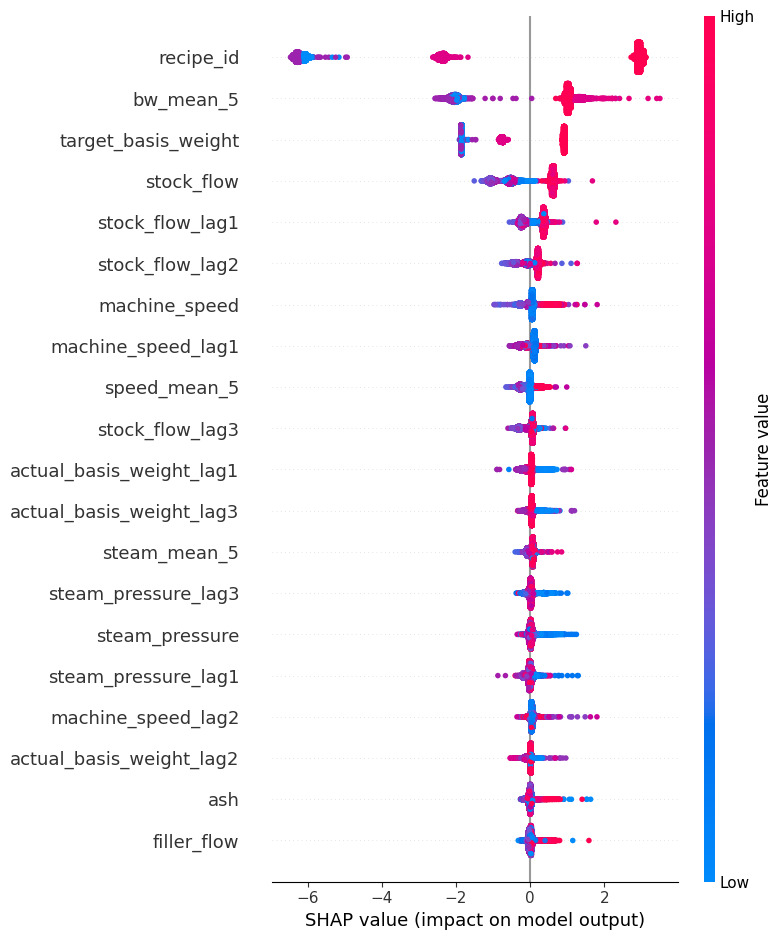

In [ ]:
shap.summary_plot(
    shap_values,
    X
)

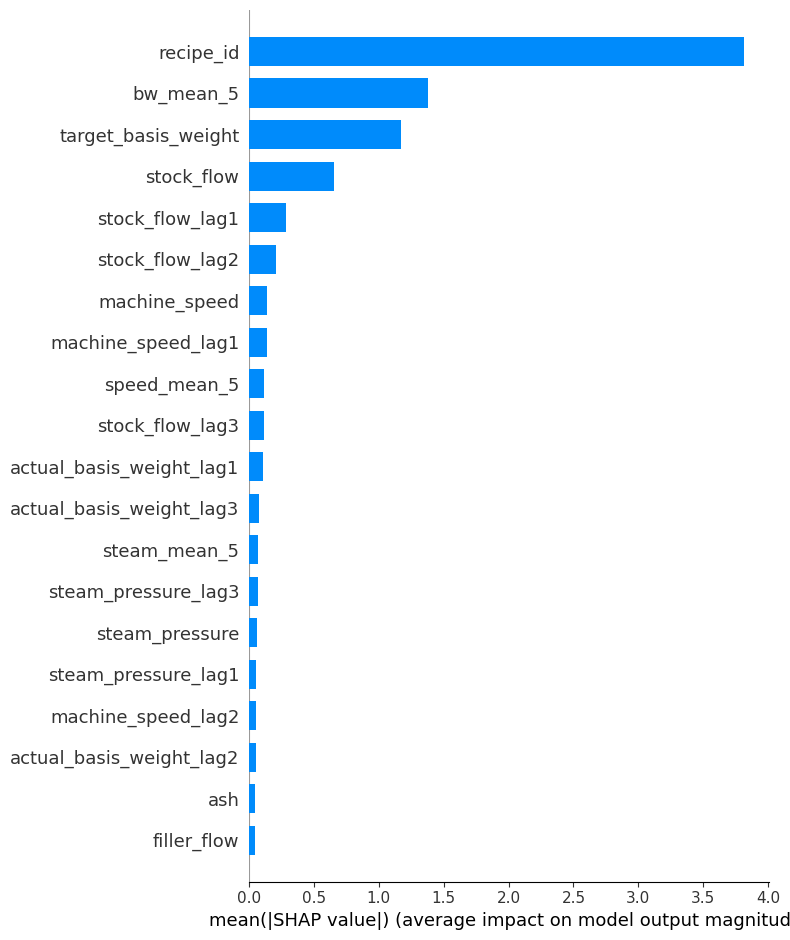

In [ ]:
shap.summary_plot(
    shap_values,
    X,
    plot_type="bar"
)

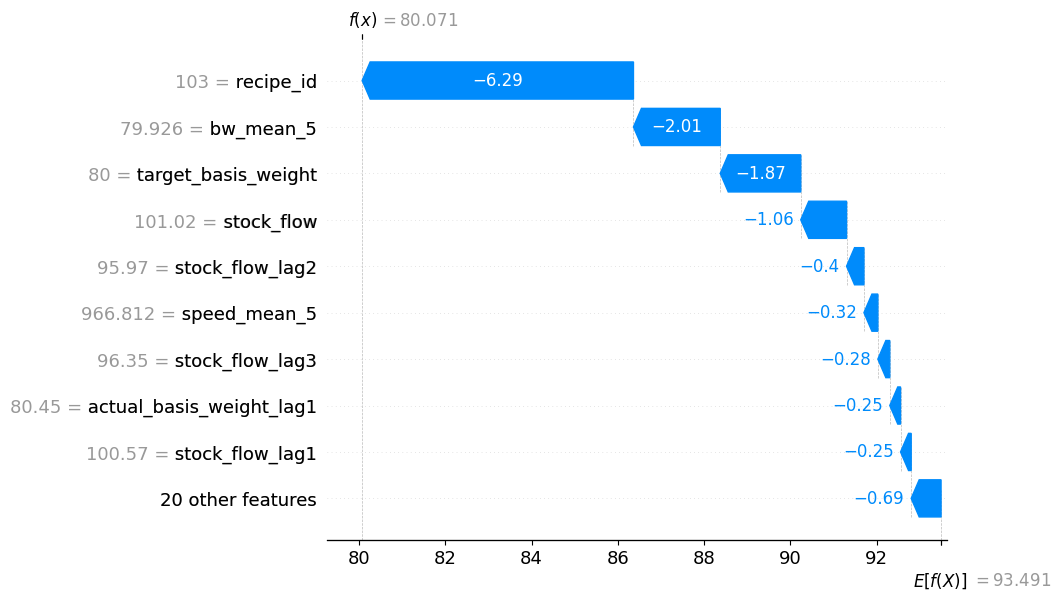

In [ ]:
sample_index = 500

sample = X.iloc[[sample_index]]

sample_shap = explainer(sample)

shap.plots.waterfall(sample_shap[0])

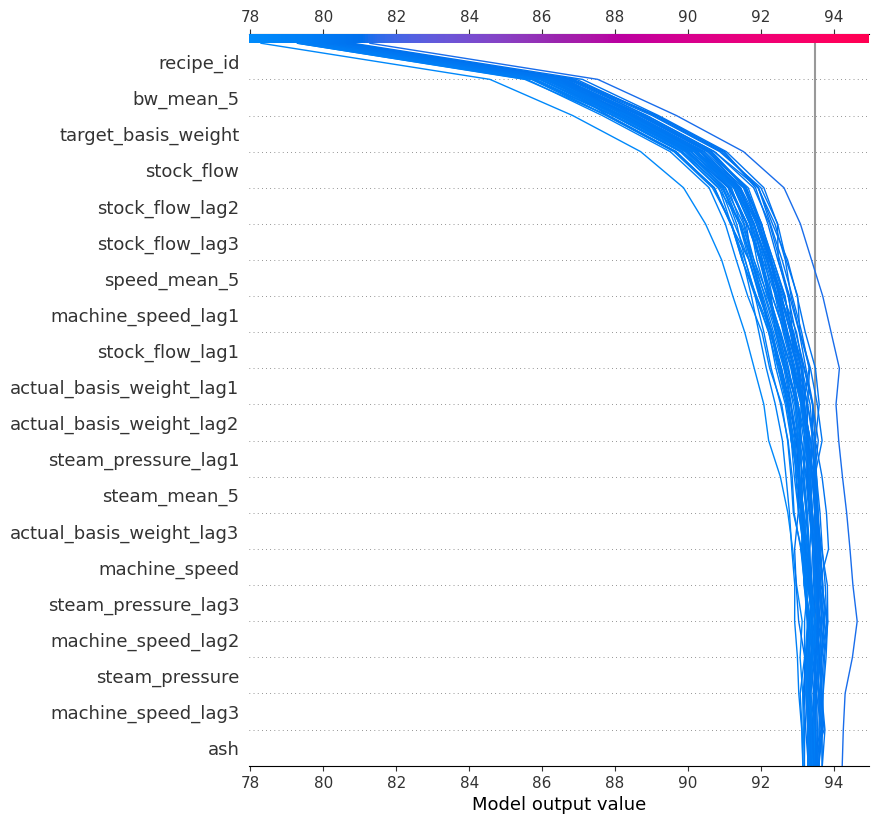

In [ ]:
shap.decision_plot(
    explainer.expected_value,
    shap_values[:50],
    X.iloc[:50]
)

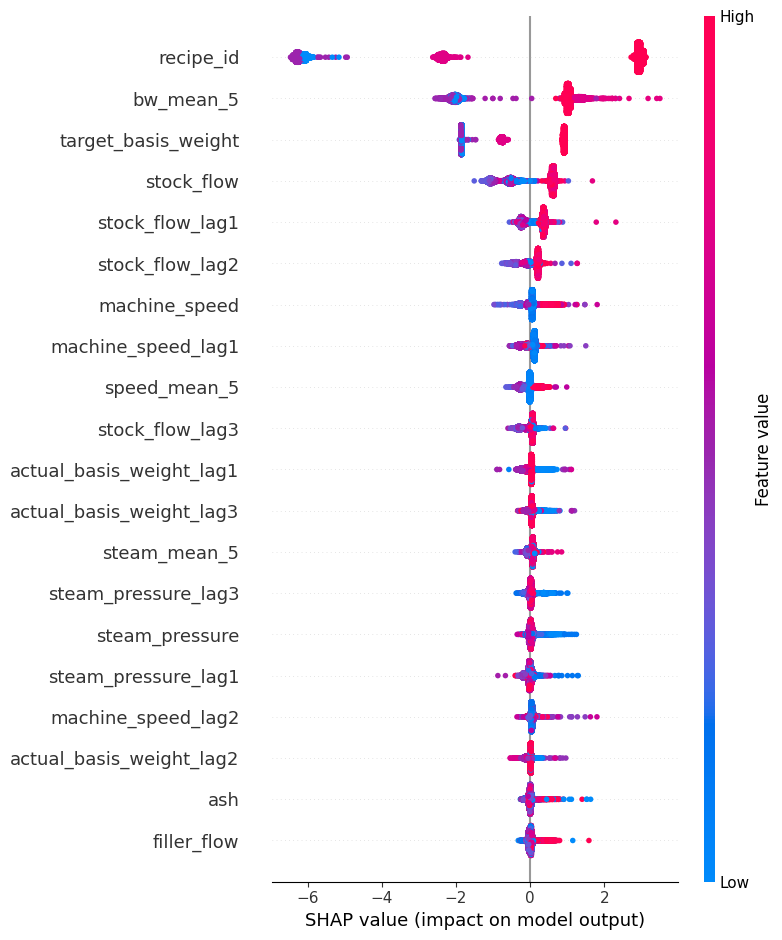

In [ ]:
shap.summary_plot(
    shap_values,
    X,
    show=False
)

plt.savefig(
    "future_prediction_shap.png",
    dpi=300,
    bbox_inches="tight"
)

In [ ]:
files.download("future_prediction_shap.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>